In [2]:
### Read files
import pandas as pd

real_result_baseline_file_tel = "eval/mutation_results/qucheck_quantum_teleportation_merged_results.csv"
real_result_baseline_file_sdc = "eval/mutation_results/qucheck_superdense_coding_merged_results.csv"
real_result_qismc_file_tel = "eval/mutation_results/quantum_teleportation_results.csv"
real_result_qismc_file_sdc = "eval/mutation_results/superdense_coding_results.csv"
df_qucheck_tel = pd.read_csv(real_result_baseline_file_tel)
df_qucheck_sdc = pd.read_csv(real_result_baseline_file_sdc)
df_qismc_tel = pd.read_csv(real_result_qismc_file_tel)
df_qismc_sdc = pd.read_csv(real_result_qismc_file_sdc)

def selectDataFrame(df: pd.DataFrame, input=64, meas=3200):
    # 挑选出 Number of Inputs = 64 且 Number of Measurements = 3200 的行
    filtered_df = df[
        (df["Number of Inputs"] == input) &
        (df["Number of Measurements"] == meas)
    ].copy()
    # 只保留 Mutant Name, Result, Time Taken 三列
    selected_df = filtered_df[["Mutant Name", "Result", "Time Taken"]]
    return selected_df

def selectDataFrame_withMeas(df: pd.DataFrame, input=64, measurements=[800, 1600, 3200]):
    frames = []
    for meas in measurements:
        filtered_df = df[
            (df["Number of Inputs"] == input) &
            (df["Number of Measurements"] == meas)
        ].copy()
        filtered_df["Measurements"] = meas
        selected_df = filtered_df[["Mutant Name", "Result", "Time Taken", "Measurements"]]
        frames.append(selected_df)
    return pd.concat(frames, ignore_index=True)

# 应用到 QuCheck
# df_qucheck_tel = selectDataFrame(df_qucheck_tel)
# df_qucheck_sdc = selectDataFrame(df_qucheck_sdc)
df_qucheck_tel = selectDataFrame_withMeas(df_qucheck_tel)
df_qucheck_sdc = selectDataFrame_withMeas(df_qucheck_sdc)
df_qismc_tel = df_qismc_tel[["satisfied", "prepare_time", "model_time", "mutant"]]
# df_qismc_sdc originally only has the above four columns
# get a new column called Time Taken, which is the summation of prepare_time and model_time
df_qismc_sdc["Time Taken"] = df_qismc_sdc["prepare_time"] + df_qismc_sdc["model_time"]
df_qismc_tel["Time Taken"] = df_qismc_tel["prepare_time"] + df_qismc_tel["model_time"]
df_qismc_tel = df_qismc_tel.rename(columns={"satisfied": "Result", "mutant": "Mutant Name"})
df_qismc_tel = df_qismc_tel[["Mutant Name", "Result", "Time Taken"]]
df_qismc_sdc = df_qismc_sdc.rename(columns={"satisfied": "Result", "mutant": "Mutant Name"})
df_qismc_sdc = df_qismc_sdc[["Mutant Name", "Result", "Time Taken"]]
# All Time Taken, from s to ms
df_qucheck_tel["Time Taken"] = df_qucheck_tel["Time Taken"] * 1000
df_qucheck_sdc["Time Taken"] = df_qucheck_sdc["Time Taken"] * 1000
df_qismc_tel["Time Taken"] = df_qismc_tel["Time Taken"] * 1000
df_qismc_sdc["Time Taken"] = df_qismc_sdc["Time Taken"] * 1000

quantum_teleportation_results.csv

64,True,1.0,0.0002040863037109375,0.06003069877624512,original

superdense_coding_results.csv

True,0.03002786636352539,0.011491060256958008,original

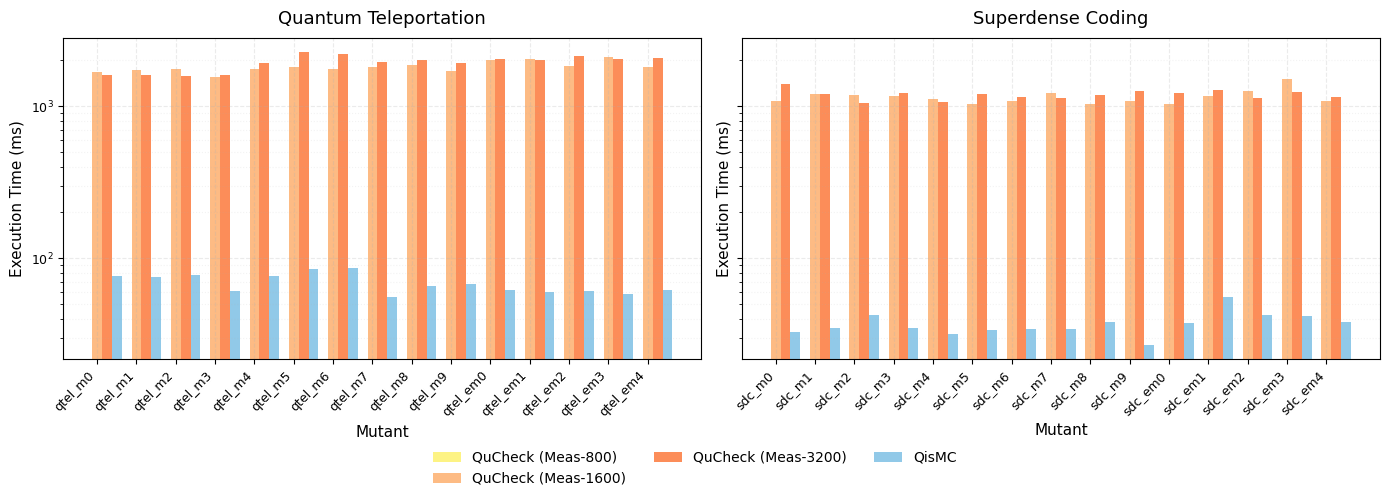

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# === Step 1: 组装数据 ===
def prepare_plot_df(df_qucheck, df_qismc):
    df_plot_qucheck = df_qucheck.copy()
    df_plot_qucheck["Algorithm"] = df_plot_qucheck["Measurements"].map(lambda x: f"QuCheck (Meas-{x})")

    df_plot_qismc = df_qismc.copy()
    df_plot_qismc["Algorithm"] = "QisMC"
    df_plot_qismc["Measurements"] = 3200  # for uniformity

    df_plot_all = pd.concat([df_plot_qucheck, df_plot_qismc], ignore_index=True)
    return df_plot_all

df_tel_all = prepare_plot_df(df_qucheck_tel, df_qismc_tel)
df_sdc_all = prepare_plot_df(df_qucheck_sdc, df_qismc_sdc)

# === Step 2: 通用绘图函数 ===
def plot_experiment(ax, df_all, title):
    mutants = df_all["Mutant Name"].unique()
    algorithms = ["QuCheck (Meas-800)", "QuCheck (Meas-1600)", "QuCheck (Meas-3200)", "QisMC"]

    x = np.arange(len(mutants))
    width = 0.25

    # 获取每种算法对应的时间
    means = []
    for alg in algorithms:
        times = []
        for m in mutants:
            val = df_all[(df_all["Mutant Name"] == m) &
                         (df_all["Algorithm"] == alg)]["Time Taken"]
            times.append(val.values[0] if not val.empty else np.nan)
        means.append(times)

    colors = ["#FDF384","#FDBB84", "#FC8D59", "#91C9E8"]

    for i, alg in enumerate(algorithms):
        ax.bar(x + (i - 1) * width, means[i], width, label=alg, color=colors[i])

    ax.set_yscale("log")
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel("Mutant", fontsize=11)
    ax.set_ylabel("Execution Time (ms)", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(mutants, rotation=45, ha="right", fontsize=9)
    ax.grid(True, which="major", linestyle="--", alpha=0.25)
    ax.grid(True, which="minor", linestyle=":", alpha=0.15)
    ax.tick_params(axis='y', labelsize=9)

# === Step 3: 绘制横向排列的两个子图 ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

plot_experiment(axes[0], df_tel_all, "Quantum Teleportation")
plot_experiment(axes[1], df_sdc_all, "Superdense Coding")

# 统一图例（放在下方居中）
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=10, frameon=False)

# 调整布局
plt.tight_layout(rect=[0, 0.08, 1, 1])  # 给底部图例留空间
plt.show()
# save as pdf
fig.savefig('output/runtime_comparison_qcheck_qismc_meas.pdf', format='pdf', bbox_inches='tight')

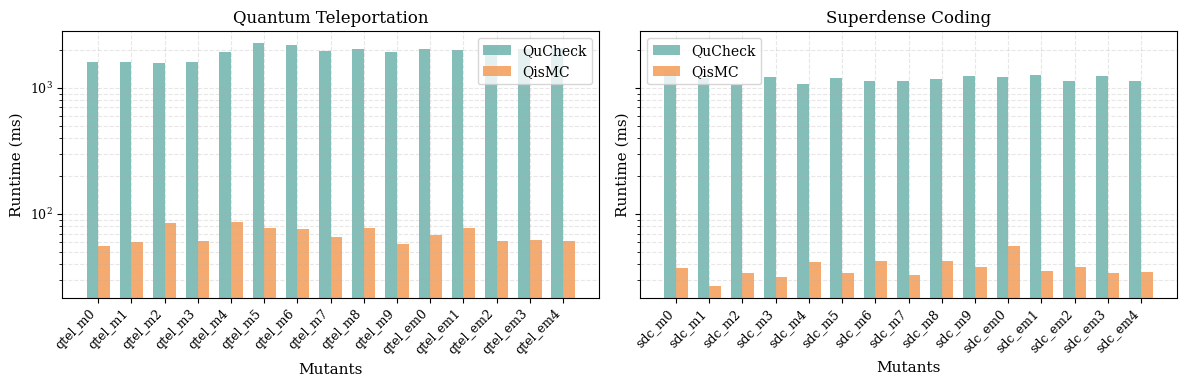

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ======================
# 1. 准备虚拟实验数据
# ======================
np.random.seed(42)
n_samples = 15

# 两组实验名称
experiments = ["Quantum Teleportation", "Superdense Coding"]

# baseline 和你的算法的运行时间（单位：ms）
# baseline_times = [
#     np.random.uniform(50, 100, n_samples),   # teleportation
#     np.random.uniform(80, 150, n_samples)    # superdense coding
# ]
# Real data from qucheck
baseline_times = [
    df_qucheck_tel["Time Taken"].head(n_samples).tolist(),
    df_qucheck_sdc["Time Taken"].head(n_samples).tolist()
]
baseline_names = [
    df_qucheck_tel["Mutant Name"].head(n_samples).tolist(),
    df_qucheck_sdc["Mutant Name"].head(n_samples).tolist()
]

# ours_times = [baseline / np.random.uniform(8, 12) for baseline in baseline_times]
ours_times = [
    df_qismc_tel["Time Taken"].head(n_samples).tolist(),
    df_qismc_sdc["Time Taken"].head(n_samples).tolist()
]
ours_names = [
    df_qismc_tel["Mutant Name"].head(n_samples).tolist(),
    df_qismc_sdc["Mutant Name"].head(n_samples).tolist()
]


# ======================
# 2. 绘制对数坐标柱状图
# ======================
plt.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
bar_width = 0.35
x = np.arange(n_samples)

for ax, exp_name, base, ours, names in zip(axes, experiments, baseline_times, ours_times, baseline_names):
    # 绘制两组柱
    # "#4E79A7" "#F28E2B"
    ax.bar(x - bar_width/2, base, bar_width, label='QuCheck', color="#76B7B2", alpha=0.9)
    ax.bar(x + bar_width/2, ours, bar_width, label='QisMC', color="#F4A261", alpha=0.9)
    
    # 对数坐标 + 网格
    ax.set_yscale('log')
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    
    # 坐标轴与标题
    ax.set_xlabel('Mutants')
    ax.set_ylabel('Runtime (ms)')
    ax.set_title(exp_name)
    ax.legend()
    
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right')

# 总标题
# fig.suptitle('Runtime Comparison on Two Quantum Benchmarks', fontsize=14, fontweight='bold', y=0.98)

# 调整布局
plt.tight_layout()
plt.show()
# Save as pdf
fig.savefig('output/runtime_comparison_qcheck_qismc_withouthead.pdf', format='pdf', bbox_inches='tight')

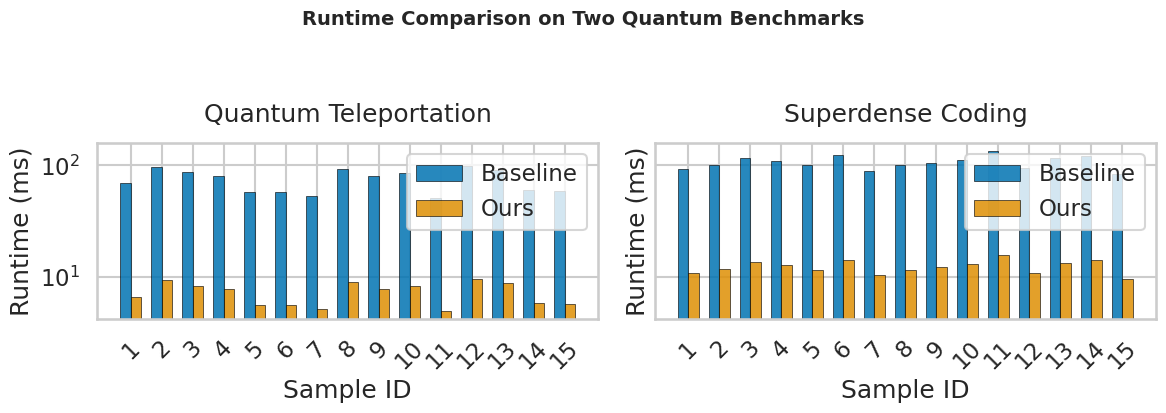

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ======================
# 1. 数据准备
# ======================
np.random.seed(42)
n_samples = 15

experiments = ["Quantum Teleportation", "Superdense Coding"]
baseline_times = [
    np.random.uniform(50, 100, n_samples),
    np.random.uniform(80, 150, n_samples)
]
ours_times = [baseline / np.random.uniform(8, 12) for baseline in baseline_times]

# ======================
# 2. Seaborn 风格设置
# ======================
sns.set_theme(style="whitegrid", context="talk", palette="colorblind")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
bar_width = 0.35
x = np.arange(n_samples)

# 调色板
colors = sns.color_palette("colorblind")

for ax, exp_name, base, ours in zip(axes, experiments, baseline_times, ours_times):
    # 绘制两组柱状
    ax.bar(x - bar_width/2, base, bar_width, label='Baseline', color=colors[0], alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.bar(x + bar_width/2, ours, bar_width, label='Ours', color=colors[1], alpha=0.85, edgecolor='black', linewidth=0.5)

    # 对数坐标
    ax.set_yscale('log')
    ax.set_xlabel('Sample ID')
    ax.set_ylabel('Runtime (ms)')
    ax.set_title(exp_name, pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels([str(i+1) for i in range(n_samples)], rotation=45)
    ax.legend(frameon=True, loc='upper right')

# 总标题与布局
fig.suptitle('Runtime Comparison on Two Quantum Benchmarks', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()

# 导出为论文插图
# plt.savefig("runtime_comparison_seaborn.pdf", bbox_inches='tight')
plt.show()

In [13]:
df_grover = pd.read_csv("eval/scale_debug/grover_results_inj_1106.csv")
df_grover_filter = df_grover[df_grover["num_qubits"] % 5 == 0]
df_grover_filter.to_csv("eval/scale_debug/grover_results_inj_1106_filtered.csv", index=False)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

NAME_DICT = {
    "eval/scale/dqc_qft_results.csv": "DQC_QFT",
    "eval/scale/qft_results.csv": "QFT",
    "eval/scale/grover_results_filtered.csv": "Grover",
    "eval/scale/pe_results.csv": "DQC_PE",
    "eval/scale_debug/benchpress_medium_inj.csv": "Benchpress_Medium",
    "eval/scale_debug/dqc_pe_results_inj.csv": "DQC_PE_DEBUG",
    "eval/scale_debug/grover_results_inj_filtered.csv": "Grover_DEBUG",
    "eval/scale_debug/grover_results_inj_1106_filtered.csv": "Grover_DEBUG"
}

# df_grover = pd.read_csv("eval/scale/grover_results.csv")
# df_grover_filter = df_grover[df_grover["num_qubits"] % 5 == 0]
# df_grover_filter.to_csv("eval/scale/grover_results_filtered.csv", index=False)

def generate_scale_figure(filename="eval/scale/dqc_qft_results.csv",logscale_left=True, logscale_right=True, append_veri_time=False):
    global NAME_DICT
    # 读取 CSV 数据
    df = pd.read_csv(filename)

    # 基本参数
    # x = df["num_qubits"]
    x_vals = df["num_qubits"]
    x_idx = np.arange(len(x_vals))
    time_prepare = df["time_prepare_ts"]
    time_post = df["time_fixed_point_post"]
    if append_veri_time:
        time_post += df["verification_time"]
    time_total = time_prepare + time_post
    num_gates = df["num_gates"]
    num_locations = df["num_locations"]

    # 创建图形与双坐标轴
    fig, ax1 = plt.subplots(figsize=(7, 4))

    # 调整总体风格（非 seaborn，干净风格）
    plt.style.use("default")
    plt.rcParams.update({
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.alpha": 0.5
    })

    # ---------- 左轴：时间的堆叠柱状图 ----------
    width = 0.35
    ax1.bar(x_idx, time_prepare, width, label="Time (prepare_ts)", color="#7db5d8", alpha=0.8)
    ax1.bar(x_idx, time_post, width, bottom=time_prepare, label="Time (checking)", color="#f2a444", alpha=0.8)

    # 在柱状图顶端添加总时间虚线
    # ax1.plot(x_idx, time_total, color="black", linestyle="--", marker="o", markersize=4, label="Total time")

    ax1.set_xlabel("Number of qubits")
    ax1.set_ylabel(f"Execution time (s{', log scale' if logscale_left else ''})")
    ax1.tick_params(axis='y')
    ax1.set_title(f"{NAME_DICT[filename]} performance metrics")
    if logscale_left:
        ax1.set_yscale("log")

    # ---------- 右轴：num_gates 和 num_locations ----------
    ax2 = ax1.twinx()
    ax2.plot(x_idx, num_gates, color="#2b8cbe", marker="s", markersize=5, label="Num. of gates")
    ax2.plot(x_idx, num_locations, color="#de2d26", marker="^", markersize=5, label="Num. of locations")

    ax2.set_ylabel(f"Counts{' (log scale)' if logscale_right else ''}")
    ax2.tick_params(axis='y')
    if logscale_right:
        ax2.set_yscale("log")

    # ---------- 图例处理 ----------
    # 合并两侧图例
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", frameon=False)

    # ---------- 细节优化 ----------
    ax1.set_xticks(x_idx)
    ax1.set_xticklabels([str(q) for q in x_vals])
    ax1.margins(x=0.05)
    fig.tight_layout()

    # 保存或显示
    # save as pdf
    fig.savefig(f"output/scale_{NAME_DICT[filename].lower()}.pdf", format='pdf', bbox_inches='tight')
    plt.show()

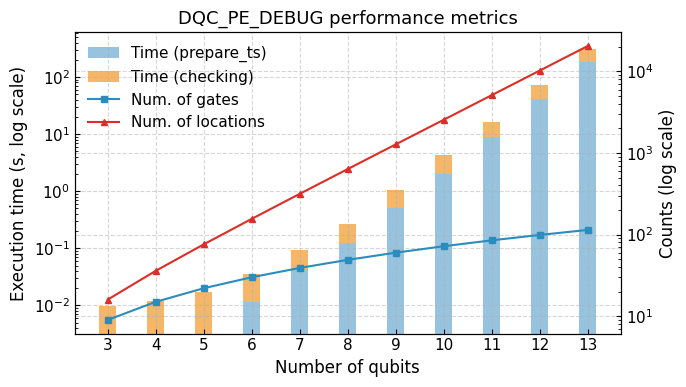

In [8]:
generate_scale_figure("eval/scale_debug/dqc_pe_results_inj.csv", append_veri_time=True)

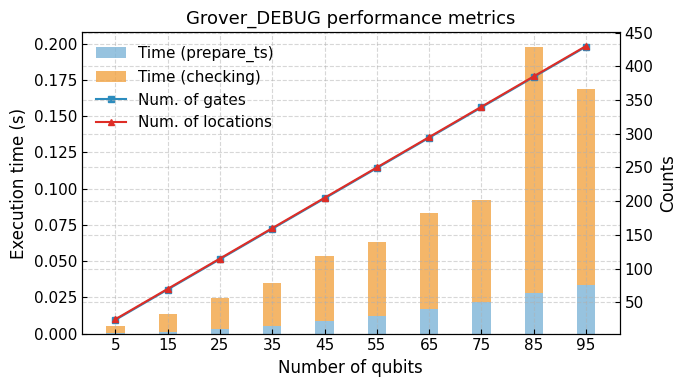

In [15]:
generate_scale_figure("eval/scale_debug/grover_results_inj_filtered.csv", logscale_left=False,logscale_right=False, append_veri_time=True)

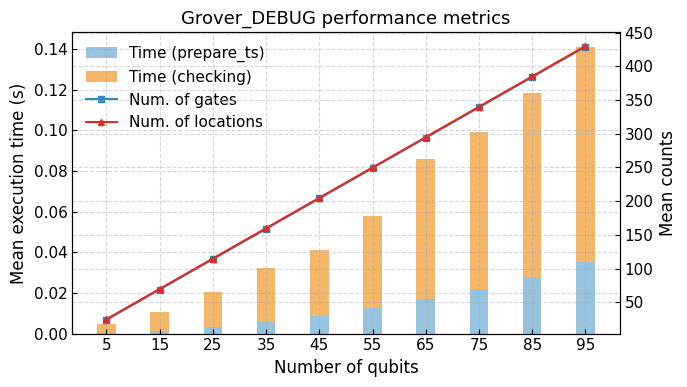

In [18]:
generate_scale_figure("eval/scale_debug/grover_results_inj_1106_filtered.csv", logscale_left=False,logscale_right=False, append_veri_time=True)

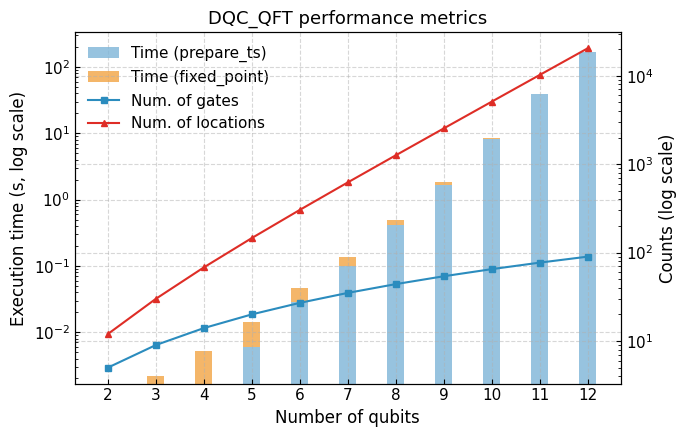

In [ ]:
generate_scale_figure("eval/scale/dqc_qft_results.csv")

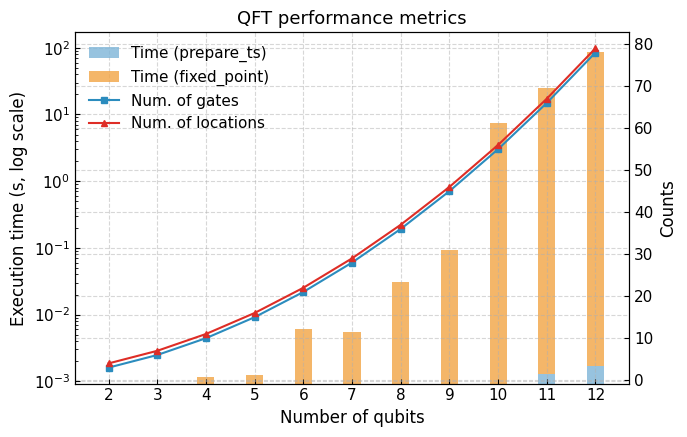

In [ ]:
generate_scale_figure("eval/scale/qft_results.csv", logscale_right=False)

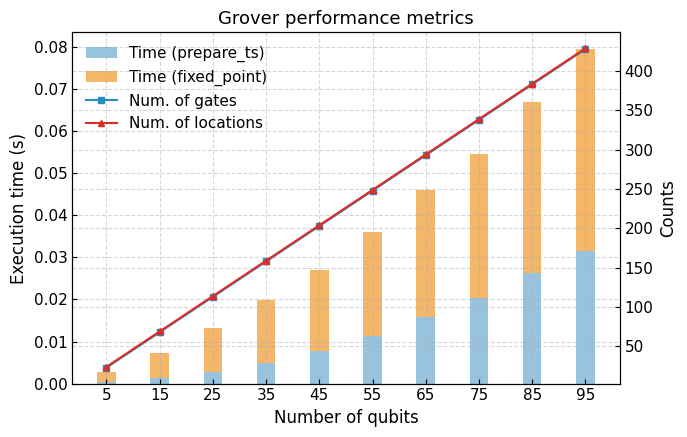

In [ ]:
generate_scale_figure("eval/scale/grover_results_filtered.csv", logscale_left=False,logscale_right=False)

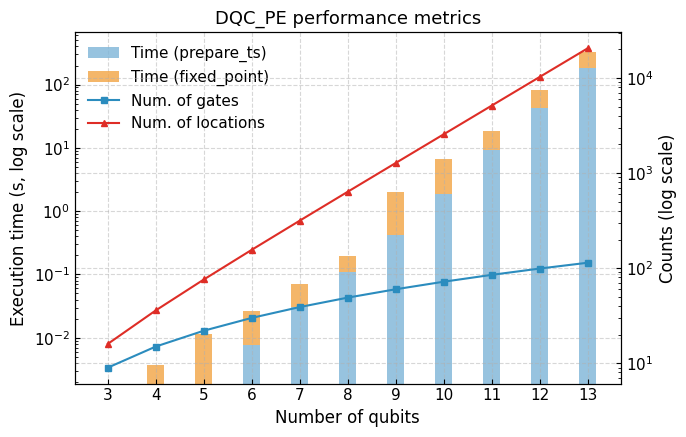

In [ ]:
generate_scale_figure("eval/scale/pe_results.csv")

In [10]:
import csv
import os

# 输入 CSV 文件路径
csv_file = "eval/scale_debug/benchpress_medium_inj.csv"

# 打开并读取 CSV
with open(csv_file, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        # 提取文件名主体（去掉路径和后缀）
        program_name = os.path.splitext(os.path.basename(row["filename"]))[0]

        # 读取各字段
        num_qubits = row["num_qubits"]
        num_gates = row["num_gates"]
        debug_info = row["debug_info"]
        prep_time = float(row["time_prepare_ts"])
        veri_time = float(row["time_fixed_point_post"]) + float(row["verification_time"])

        # 格式化数字
        prep_time_str = f"{prep_time:.3f}"
        veri_time_str = f"{veri_time:.2f}"

        # 输出 LaTeX 表格行
        print(f"{program_name} & {num_qubits} & {num_gates} & {debug_info} & {prep_time_str} & {veri_time_str}\\\\")

qf21_n15 & 15 & 80 & False & 0.003 & 39.91\\
qec9xz_n17 & 17 & 62 & False & 2.822 & 6.76\\
qf21_n15_transpiled & 15 & 366 & False & 0.032 & 160.22\\
multiply_n13_transpiled & 13 & 124 & False & 0.008 & 0.05\\
seca_n11 & 11 & 81 & False & 0.011 & 0.07\\
bigadder_n18_transpiled & 18 & 340 & False & 0.657 & 1.38\\
qram_n20_transpiled & 20 & 351 & False & 0.044 & 0.16\\
bv_n14 & 14 & 57 & False & 133.895 & 245.26\\
cc_n12 & 12 & 62 & False & 38.223 & 60.61\\
seca_n11_transpiled & 11 & 293 & False & 0.260 & 0.66\\
multiplier_n15 & 15 & 74 & False & 0.003 & 0.02\\
square_root_n18_transpiled & 18 & 2788 & False & 187.837 & 309.97\\
sat_n11 & 11 & 96 & False & 0.006 & 0.09\\
square_root_n18 & 18 & 559 & False & 172.912 & 244.14\\
cc_n12_transpiled & 12 & 130 & False & 46.108 & 68.81\\
multiply_n13 & 13 & 22 & False & 0.003 & 0.02\\
qec9xz_n17_transpiled & 17 & 104 & False & 0.256 & 0.50\\
sat_n11_transpiled & 11 & 736 & False & 0.173 & 2.03\\
qram_n20 & 20 & 46 & False & 0.003 & 0.02\\
multipl

In [12]:
import pandas as pd

grover_file = "eval/scale_debug/grover_results_inj_1106.csv"
file = pd.read_csv(grover_file)
# compute the average of column debug_satisfaction_percent
avg_debug_satisfaction = 100-file["debug_satisfaction_percent"].mean()
print(f"Average debug satisfaction percent: {avg_debug_satisfaction}%")

Average debug satisfaction percent: 79.6734693877551%
